**Anggota Kelommpok:**

1. Cindy Natasa (103102400024)
2. Muhammad Alfayyadh Nezzati Qosim (103102400029)
3. Khalid Muhammad (103102400033)
4. Ivana Gabby Lauretta (103102400037)
5. Evelyna Angie (103102400040)

**Fall Detection dan Prediksi Sebelum**

**Urgensi**

Fall Detection merupakan sistem pengawasan yang dapat diimplementasikan di lingkungan yang perlu pemantauan seperti panti jompo dan rumah sakit. Fall detection dapat efektif ketika respons cepat sehingga berpotensi menyelamatkan nyawa dan mengurangi dampak cidera akibat jatuh.

Citra CCTV ini berisi data visual yang nantinya bisa untuk menganalisis postur dan aktivitas manusia. Klasifikasi dibagi menjadi 3, seperti "Normal", "Pre-Fall", dan "Fall". Deteksi Pre-Fall bisa memberikan warning lebih cepat kepada petugas/orang yang bertanggung jawab untuk melakukan tindakan. Maka dari itu, model ini diharapkan mampu membedakan tiga kondisi tersebut.

# Novelty

Penelitian ini menekankan deteksi jatuh dari citra CCTV dengan tiga kelas: Normal, Pre-Fall, dan Fall. Model dibangun menggunakan ResNet50 dan transfer learning agar lebih baik dalam mengenali pose manusia. Selain itu, data kelas minoritas diseimbangkan dengan oversampling supaya hasil prediksi lebih seimbang.

# Tujuan

- Mengembangkan sistem deteksi jatuh dari citra CCTV.
- Membagi kondisi menjadi tiga kelas: Normal, Pre-Fall, dan Fall.
- Memberikan peringatan lebih awal sebelum jatuh terjadi.
- Meningkatkan akurasi model dengan pendekatan deep learning dan data yang lebih seimbang.

# Metode yang Digunakan

Data gambar berasal dari dua kumpulan citra CCTV yang sudah diberi label pose. Gambar diubah ke ukuran 224×224, dinormalisasi, dan diberi augmentasi agar model lebih kuat saat melatih. Model yang digunakan adalah ResNet50 dengan pretrained ImageNet untuk klasifikasi 3 kelas. Karena data tidak seimbang, kelas minoritas ditambah dengan oversampling. Evaluasi dilakukan dengan akurasi, precision, recall, F1-score, dan confusion matrix.

**Program Lengkap**

In [ ]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import matplotlib.pyplot as plt

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch:", torch.__version__)
print("Device :", device)


PyTorch: 2.11.0+cu128
Device : cuda


In [ ]:
# =======================
# CELL 3 - Setting utama
# =======================
# UBAH PATH INI sesuai lokasi dataset kamu di laptop.
TRAIN_DIR = r"C:\Users\HP\DataspellProjects\College\MachineLearning\1954"
TEST_DIR  = r"C:\Users\HP\DataspellProjects\College\MachineLearning\832\832"

# Pakai RGB karena sesuai topik citra CCTV.
IMAGE_MODE = "rgb"

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 10
RANDOM_STATE = 42

# Tambahan baru:
# kelas Fall dibuat seimbang dengan kelas Normal hanya pada data train.
USE_FALL_OVERSAMPLING = True

OUTPUT_DIR = Path("outputs_oversampling_fall")
OUTPUT_DIR.mkdir(exist_ok=True)

MODEL_NAME = "fall_resnet50_rgb_oversampling_fall.keras"
MODEL_PATH = OUTPUT_DIR / MODEL_NAME

USE_IMAGENET_WEIGHTS = True

In [ ]:
# ===============================================
# CELL 4 - Aturan label dataset (UPDATE 3 KELAS)
# ===============================================
POSE_CLASS_NAMES = {
    0: "Empty", 1: "Standing", 2: "Sitting",
    3: "Lying", 4: "Bending", 5: "Crawling", 6: "Empty"
}

# Definisikan kelas baru
PRE_FALL_POSE_CLASSES = [4] # Bending = Transisi akan jatuh
FALL_POSE_CLASSES = [3, 5]  # Lying, Crawling = Jatuh

# 0: Normal, 1: Pre-Fall, 2: Fall
MULTI_LABEL_NAMES = {
    0: "Normal",
    1: "Pre-Fall",
    2: "Fall"
}

print("Pose Pre-Fall :", [POSE_CLASS_NAMES[x] for x in PRE_FALL_POSE_CLASSES])
print("Pose Fall     :", [POSE_CLASS_NAMES[x] for x in FALL_POSE_CLASSES])

Pose Pre-Fall : ['Bending']
Pose Fall     : ['Lying', 'Crawling']


In [ ]:
# =========================================================
# CELL 5 - Fungsi membaca labels (UPDATE 3 TARGET)
# =========================================================
def make_dataframe(root_dir: str, image_mode: str = "rgb") -> pd.DataFrame:
    root = Path(root_dir)
    labels_path = root / "labels.csv"

    if not labels_path.exists():
        raise FileNotFoundError(f"labels.csv tidak ditemukan di: {labels_path}")

    df = pd.read_csv(labels_path)

    if "index" not in df.columns or "class" not in df.columns:
        df = pd.read_csv(labels_path, header=None)
        df.columns = ["index", "class"]

    df["index"] = df["index"].astype(int)
    df["pose_class_original"] = df["class"].astype(int)

    df["pose_class"] = df["pose_class_original"].replace({6: 0})
    df["pose_name"] = df["pose_class"].map(POSE_CLASS_NAMES)

    prefix = "rgb" if image_mode.lower() == "rgb" else "depth"
    image_folder = root / prefix

    df["filename"] = df["index"].apply(lambda x: f"{prefix}_{int(x):04d}.png")
    df["filepath"] = df["filename"].apply(lambda x: str(image_folder / x))

    # --- LOGIKA LABEL 3 KELAS ---
    def assign_label(pose):
        if pose in FALL_POSE_CLASSES:
            return 2 # Fall
        elif pose in PRE_FALL_POSE_CLASSES:
            return 1 # Pre-Fall
        else:
            return 0 # Normal

    df["label"] = df["pose_class"].apply(assign_label)
    df["label_name"] = df["label"].map(MULTI_LABEL_NAMES)

    df["file_exists"] = df["filepath"].apply(os.path.exists)

    missing = df[~df["file_exists"]]
    if len(missing) > 0:
        print("PERINGATAN: ada file gambar yang tidak ditemukan, akan dilewati.")
        display(missing[["index", "filename", "filepath"]].head(20))
        print("Total missing:", len(missing))

    df = df[df["file_exists"]].reset_index(drop=True)
    return df

In [ ]:
class FallDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

        self.transform = transforms.Compose([
            transforms.Resize(IMG_SIZE),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(5),

            transforms.ToTensor(),

            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["filepath"]).convert("RGB")
        image = self.transform(image)

        label = torch.tensor(
            row["label"],
            dtype=torch.float32
        )

        return image, label

In [ ]:
# =========================================================
# CELL 7 - Fungsi melihat distribusi data
# =========================================================
def show_distribution(name: str, df: pd.DataFrame):
    """Menampilkan jumlah data berdasarkan label Normal/Fall dan pose asli."""
    print(f"\nDistribusi label biner - {name}")
    print(df["label_name"].value_counts().to_string())

    print(f"\nDistribusi pose asli - {name}")
    pose_dist = df["pose_name"].value_counts()
    print(pose_dist.to_string())

    return pose_dist

In [ ]:
# ==========================
# CELL 8 - Membaca dataset
# ==========================
train_all_df = make_dataframe(TRAIN_DIR, IMAGE_MODE)
test_df = make_dataframe(TEST_DIR, IMAGE_MODE)

print("Jumlah data train 722 setelah cek file:", len(train_all_df))
print("Jumlah data test 832 setelah cek file :", len(test_df))

display(train_all_df.head())
display(test_df.head())

Jumlah data train 722 setelah cek file: 1954
Jumlah data test 832 setelah cek file : 832


,index,class,pose_class_original,pose_class,pose_name,filename,filepath,label,label_name,file_exists
0,1,6,6,0,Empty,rgb_0001.png,C:\Users\HP\DataspellProjects\College\MachineL...,0,Normal,True
1,2,6,6,0,Empty,rgb_0002.png,C:\Users\HP\DataspellProjects\College\MachineL...,0,Normal,True
2,3,6,6,0,Empty,rgb_0003.png,C:\Users\HP\DataspellProjects\College\MachineL...,0,Normal,True
3,4,6,6,0,Empty,rgb_0004.png,C:\Users\HP\DataspellProjects\College\MachineL...,0,Normal,True
4,5,6,6,0,Empty,rgb_0005.png,C:\Users\HP\DataspellProjects\College\MachineL...,0,Normal,True


,index,class,pose_class_original,pose_class,pose_name,filename,filepath,label,label_name,file_exists
0,1,6,6,0,Empty,rgb_0001.png,C:\Users\HP\DataspellProjects\College\MachineL...,0,Normal,True
1,2,6,6,0,Empty,rgb_0002.png,C:\Users\HP\DataspellProjects\College\MachineL...,0,Normal,True
2,3,6,6,0,Empty,rgb_0003.png,C:\Users\HP\DataspellProjects\College\MachineL...,0,Normal,True
3,4,6,6,0,Empty,rgb_0004.png,C:\Users\HP\DataspellProjects\College\MachineL...,0,Normal,True
4,5,6,6,0,Empty,rgb_0005.png,C:\Users\HP\DataspellProjects\College\MachineL...,0,Normal,True


In [ ]:
# ==============================
# CELL 9 - Cek distribusi label
# ==============================
show_distribution("Train 1954 sebelum split", train_all_df)
show_distribution("Test 832", test_df)


Distribusi label biner - Train 722 sebelum split
label_name
Normal      1353
Fall         527
Pre-Fall      74

Distribusi pose asli - Train 722 sebelum split
pose_name
Standing    690
Lying       383
Empty       332
Sitting     331
Crawling    144
Bending      74

Distribusi label biner - Test 832
label_name
Normal      517
Fall        286
Pre-Fall     29

Distribusi pose asli - Test 832
pose_name
Lying       286
Sitting     286
Standing    184
Empty        47
Bending      29


pose_name
Lying       286
Sitting     286
Standing    184
Empty        47
Bending      29
Name: count, dtype: int64

In [ ]:
# =========================================================
# CELL 10 - Membagi data 1954 menjadi train dan validasi
# =========================================================
# Karena 722 dipakai sebagai data latih dan 832 sebagai test,
# maka validasi diambil dari sebagian data 722.
# Test tetap memakai data 832.

train_df, val_df = train_test_split(
    train_all_df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=train_all_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Jumlah train    :", len(train_df))
print("Jumlah validasi :", len(val_df))
print("Jumlah test     :", len(test_df))

show_distribution("Train sebelum oversampling", train_df)
show_distribution("Validasi", val_df)
show_distribution("Test", test_df)

Jumlah train    : 1563
Jumlah validasi : 391
Jumlah test     : 832

Distribusi label biner - Train sebelum oversampling
label_name
Normal      1082
Fall         422
Pre-Fall      59

Distribusi pose asli - Train sebelum oversampling
pose_name
Standing    550
Lying       304
Empty       268
Sitting     264
Crawling    118
Bending      59

Distribusi label biner - Validasi
label_name
Normal      271
Fall        105
Pre-Fall     15

Distribusi pose asli - Validasi
pose_name
Standing    140
Lying        79
Sitting      67
Empty        64
Crawling     26
Bending      15

Distribusi label biner - Test
label_name
Normal      517
Fall        286
Pre-Fall     29

Distribusi pose asli - Test
pose_name
Lying       286
Sitting     286
Standing    184
Empty        47
Bending      29


pose_name
Lying       286
Sitting     286
Standing    184
Empty        47
Bending      29
Name: count, dtype: int64

In [ ]:
# =======================================
# CELL 11 - Dataset Oversampling 3 Kelas
# =======================================
train_used_df = train_df.copy()

if USE_FALL_OVERSAMPLING:
    normal_df = train_df[train_df["label"] == 0]
    pre_fall_df = train_df[train_df["label"] == 1]
    fall_df = train_df[train_df["label"] == 2]

    target_count = len(normal_df) # Jadikan Normal sebagai patokan jumlah

    # Samakan jumlah Pre-Fall dan Fall dengan kelas Normal
    pre_fall_oversampled = pre_fall_df.sample(n=target_count, replace=True, random_state=RANDOM_STATE)
    fall_oversampled = fall_df.sample(n=target_count, replace=True, random_state=RANDOM_STATE)

    train_used_df = pd.concat([normal_df, pre_fall_oversampled, fall_oversampled], ignore_index=True)
    train_used_df = train_used_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

show_distribution("Train setelah oversampling", train_used_df)

train_dataset = FallDataset(train_used_df)
val_dataset = FallDataset(val_df)
test_dataset = FallDataset(test_df)

# num_workers=0 untuk menghindari hang di Windows
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)


Distribusi label biner - Train setelah oversampling
label_name
Fall        1082
Pre-Fall    1082
Normal      1082

Distribusi pose asli - Train setelah oversampling
pose_name
Bending     1082
Lying        787
Standing     550
Crawling     295
Empty        268
Sitting      264


In [ ]:
class FallResNet50(nn.Module):
    def __init__(self):
        super().__init__()
        weights = ResNet50_Weights.IMAGENET1K_V2 if USE_IMAGENET_WEIGHTS else None
        self.backbone = resnet50(weights=weights)

        # Ubah menjadi True agar model belajar fitur spesifik CCTV
        for param in self.backbone.parameters():
            param.requires_grad = True

        in_features = self.backbone.fc.in_features

        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, 3)
        )

    def forward(self, x):
        return self.backbone(x)

In [ ]:
# ============================
# CELL 13 - Optimizer & Loss
# ============================
model = FallResNet50().to(device)

# Ubah Loss Function untuk klasifikasi 3 Kelas
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
# =======================
# CELL 14 - Training Loop
# =======================
best_acc = 0
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

for epoch in range(EPOCHS):

    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        # UBAH: labels menjadi long() untuk CrossEntropy (tanpa unsqueeze)
        labels = labels.long().to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        # UBAH: Gunakan argmax untuk mendapatkan prediksi kelas
        preds = torch.argmax(outputs, dim=1)

        train_correct += (preds == labels).sum().item()

        train_total += labels.size(0)

    train_acc = train_correct / train_total

    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            # labels menjadi long() untuk CrossEntropy (tanpa unsqueeze)
            labels = labels.long().to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            # Gunakan argmax untuk mendapatkan prediksi kelas
            preds = torch.argmax(outputs, dim=1)

            val_correct += (preds == labels).sum().item()

            val_total += labels.size(0)

    val_acc = val_correct / val_total

    history["train_loss"].append(train_loss / len(train_loader))
    history["val_loss"].append(val_loss / len(val_loader))
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} "
        f"Train Acc={train_acc:.4f} "
        f"Val Acc={val_acc:.4f}"
    )

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), MODEL_PATH.with_suffix(".pth"))
        print("Best model saved.")

Epoch 1/10 Train Acc=0.8919 Val Acc=0.9821
Best model saved.
Epoch 2/10 Train Acc=0.9871 Val Acc=0.9795
Epoch 3/10 Train Acc=0.9852 Val Acc=0.9923
Best model saved.
Epoch 4/10 Train Acc=0.9886 Val Acc=0.9847
Epoch 5/10 Train Acc=0.9938 Val Acc=0.9872
Epoch 6/10 Train Acc=0.9945 Val Acc=0.9949
Best model saved.
Epoch 7/10 Train Acc=0.9945 Val Acc=0.9923
Epoch 8/10 Train Acc=0.9920 Val Acc=0.9949
Epoch 9/10 Train Acc=0.9975 Val Acc=0.9974
Best model saved.
Epoch 10/10 Train Acc=0.9926 Val Acc=0.9974


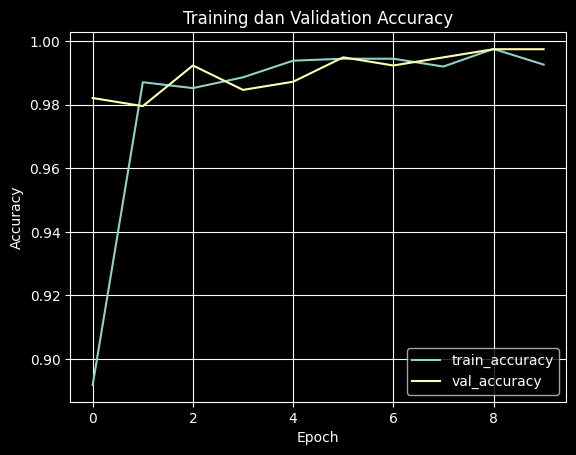

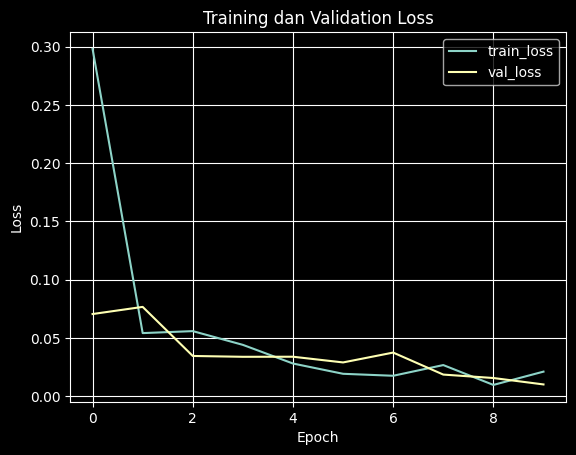

In [ ]:
# ===================================
# CELL 15 - Grafik accuracy dan loss
# ===================================
# Langsung masukkan dictionary history ke dalam DataFrame
history_df = pd.DataFrame(history)

plt.figure()
plt.plot(history_df["train_acc"], label="train_accuracy")
plt.plot(history_df["val_acc"], label="val_accuracy")
plt.title("Training dan Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(history_df["train_loss"], label="train_loss")
plt.plot(history_df["val_loss"], label="val_loss")
plt.title("Training dan Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ============================================
# CELL 16 - Evaluasi model pada data test 832
# ============================================

# Load model terbaik
checkpoint_path = MODEL_PATH.with_suffix(".pth")

if checkpoint_path.exists():

    model.load_state_dict(
        torch.load(
            checkpoint_path,
            map_location=device
        )
    )

    print(
        "Model terbaik berhasil dimuat:",
        checkpoint_path
    )

else:
    print(
        "Checkpoint tidak ditemukan, memakai model terakhir dari training."
    )

model.eval()

test_loss = 0
test_correct = 0
test_total = 0

# Loss function untuk 3 kelas
criterion = nn.CrossEntropyLoss()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        # Label diubah ke tipe long() tanpa unsqueeze
        labels = labels.long().to(device)

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        test_loss += loss.item()

        # Menggunakan argmax untuk mendapatkan prediksi kelas
        preds = torch.argmax(outputs, dim=1)

        test_correct += (
            preds == labels
        ).sum().item()

        test_total += labels.size(0)

avg_test_loss = (
    test_loss / len(test_loader)
)

test_accuracy = (
    test_correct / test_total
)

print("\nHasil evaluasi test:")
print(f"loss: {avg_test_loss:.4f}")
print(f"accuracy: {test_accuracy:.4f}")

Model terbaik berhasil dimuat: outputs_oversampling_fall\fall_resnet50_rgb_oversampling_fall.pth

Hasil evaluasi test:
loss: 0.7719
accuracy: 0.7139


In [ ]:
model.eval()

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy().flatten())
        y_prob.extend(probs.cpu().numpy().tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

report = classification_report(
    y_true,
    y_pred,
    target_names=["Normal", "Pre-Fall", "Fall"],
    digits=4,
    zero_division=0
)

print(report)

with open(OUTPUT_DIR / "classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report)

              precision    recall  f1-score   support

      Normal     0.9399    0.5745    0.7131       517
    Pre-Fall     1.0000    0.0690    0.1290        29
        Fall     0.5564    1.0000    0.7150       286

    accuracy                         0.7031       832
   macro avg     0.8321    0.5478    0.5190       832
weighted avg     0.8102    0.7031    0.6934       832



,Pred_Normal,Pred_Pre-Fall,Pred_Fall
Actual_Normal,297,0,220
Actual_Pre-Fall,19,2,8
Actual_Fall,0,0,286


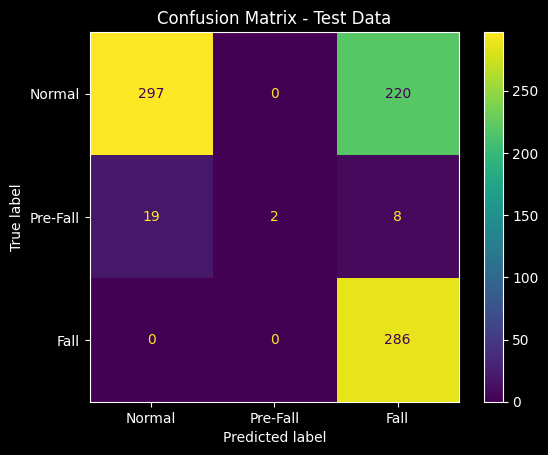

Jumlah benar : 585
Jumlah total : 832
Akurasi      : 70.31 %
Confusion matrix CSV tersimpan di: outputs_oversampling_fall\confusion_matrix.csv
Confusion matrix PNG tersimpan di: outputs_oversampling_fall\confusion_matrix.png


In [ ]:
# ===========================
# CELL 18 - Confusion matrix
# ===========================

cm = confusion_matrix(y_true, y_pred)

# Sesuaikan index dan columns menjadi 3 kelas
cm_df = pd.DataFrame(
    cm,
    index=["Actual_Normal", "Actual_Pre-Fall", "Actual_Fall"],
    columns=["Pred_Normal", "Pred_Pre-Fall", "Pred_Fall"]
)

display(cm_df)

cm_df.to_csv(
    OUTPUT_DIR / "confusion_matrix.csv"
)

# Sesuaikan display_labels menjadi 3 kelas
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Pre-Fall", "Fall"]
)

disp.plot(values_format="d")

plt.title("Confusion Matrix - Test Data")
plt.savefig(
    OUTPUT_DIR / "confusion_matrix.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

jumlah_benar = cm.trace()
jumlah_total = cm.sum()

akurasi = jumlah_benar / jumlah_total

print("Jumlah benar :", jumlah_benar)
print("Jumlah total :", jumlah_total)
print("Akurasi      :", round(akurasi * 100, 2), "%")

print(
    "Confusion matrix CSV tersimpan di:",
    OUTPUT_DIR / "confusion_matrix.csv"
)

print(
    "Confusion matrix PNG tersimpan di:",
    OUTPUT_DIR / "confusion_matrix.png"
)

In [ ]:
# =========================================================
# CELL 19 - Menyimpan hasil prediksi tiap gambar test
# =========================================================

pred_df = test_df[[
    "index",
    "filename",
    "filepath",
    "pose_class_original",
    "pose_class",
    "pose_name",
    "label",
    "label_name"
]].copy()

pred_df["pred_prob_fall"] = y_prob
pred_df["pred_label"] = y_pred

pred_df["pred_label_name"] = pred_df["pred_label"].map(MULTI_LABEL_NAMES)

pred_df["status"] = np.where(
    pred_df["label"] == pred_df["pred_label"],
    "Benar",
    "Salah"
)

pred_df.to_csv(
    OUTPUT_DIR / "test_predictions.csv",
    index=False
)

display(pred_df.head(20))

print(
    "Hasil prediksi tiap gambar tersimpan di:",
    OUTPUT_DIR / "test_predictions.csv"
)

,index,filename,filepath,pose_class_original,pose_class,pose_name,label,label_name,pred_prob_fall,pred_label,pred_label_name,status
0,1,rgb_0001.png,C:\Users\HP\DataspellProjects\College\MachineL...,6,0,Empty,0,Normal,"[0.447792112827301, 0.19822199642658234, 0.353...",0,Normal,Benar
1,2,rgb_0002.png,C:\Users\HP\DataspellProjects\College\MachineL...,6,0,Empty,0,Normal,"[0.39621296525001526, 0.1431906670331955, 0.46...",2,Fall,Salah
2,3,rgb_0003.png,C:\Users\HP\DataspellProjects\College\MachineL...,6,0,Empty,0,Normal,"[0.31183263659477234, 0.1456136852502823, 0.54...",2,Fall,Salah
3,4,rgb_0004.png,C:\Users\HP\DataspellProjects\College\MachineL...,6,0,Empty,0,Normal,"[0.3447171449661255, 0.18517038226127625, 0.47...",2,Fall,Salah
4,5,rgb_0005.png,C:\Users\HP\DataspellProjects\College\MachineL...,6,0,Empty,0,Normal,"[0.42920827865600586, 0.20713339745998383, 0.3...",0,Normal,Benar
5,6,rgb_0006.png,C:\Users\HP\DataspellProjects\College\MachineL...,6,0,Empty,0,Normal,"[0.39335694909095764, 0.17938809096813202, 0.4...",2,Fall,Salah
6,7,rgb_0007.png,C:\Users\HP\DataspellProjects\College\MachineL...,6,0,Empty,0,Normal,"[0.4085538387298584, 0.1957036703824997, 0.395...",0,Normal,Benar
7,8,rgb_0008.png,C:\Users\HP\DataspellProjects\College\MachineL...,6,0,Empty,0,Normal,"[0.4074954092502594, 0.17789803445339203, 0.41...",2,Fall,Salah
8,9,rgb_0009.png,C:\Users\HP\DataspellProjects\College\MachineL...,6,0,Empty,0,Normal,"[0.3764443099498749, 0.1905653476715088, 0.432...",2,Fall,Salah
9,10,rgb_0010.png,C:\Users\HP\DataspellProjects\College\MachineL...,6,0,Empty,0,Normal,"[0.33329445123672485, 0.18256427347660065, 0.4...",2,Fall,Salah


Hasil prediksi tiap gambar tersimpan di: outputs_oversampling_fall\test_predictions.csv


In [ ]:
# =============================================
# CELL 20 - Prediksi 10 gambar dari data test
# =============================================

predict_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


def load_single_image(image_path):

    image = Image.open(image_path).convert("RGB")

    image = predict_transform(image)

    image = image.unsqueeze(0)

    return image


def predict_one_image(
    image_path,
    threshold=0.5
):

    image_path = str(image_path)

    if not Path(image_path).exists():

        raise FileNotFoundError(
            f"Gambar tidak ditemukan: {image_path}"
        )

    image = load_single_image(
        image_path
    ).to(device)

    model.eval()

    with torch.no_grad():

        output = model(image)

        prob_fall = float(
            torch.sigmoid(output)
            .cpu()
            .numpy()[0][0]
        )

    pred_label = (
        1 if prob_fall >= threshold else 0
    )

    pred_name = (
        MULTI_LABEL_NAMES[pred_label]
    )

    return (
        pred_label,
        pred_name,
        prob_fall
    )

# Analisis Hasil

Model cukup baik dalam mengenali kelas Fall, tetapi masih kesulitan pada kelas Pre-Fall karena jumlah datanya sedikit. Hasil evaluasi menunjukkan akurasi sebesar 71.39%. Kelas Normal sering salah diprediksi sebagai Fall, sedangkan kelas Pre-Fall sering tertukar dengan Normal. Secara umum, model lebih kuat dalam membedakan Normal dan Fall dibandingkan mengenali fase sebelum jatuh. Perbaikan bisa dilakukan dengan menambah data Pre-Fall dan menyesuaikan model atau threshold klasifikasi.